In [1]:

# Initial analysis plan and setup
import numpy as np
import pandas as pd
import pickle
from scipy.signal import find_peaks
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("ANALYSIS PLAN: L_DH Inter-class Energy Ratio at Peaks")
print("=" * 80)
print("\nStep 1: Load validated L_DH coefficients and extend to N=10^6")
print("Step 2: Compute ω-class decompositions using pre-computed Ω(n) values")
print("Step 3: Find top 50 peaks in t ∈ [10^6, 2·10^6] using coarse grid + refinement")
print("Step 4: At each peak, compute canonical r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²")
print("Step 5: Compare statistics to multiplicative functions from summary table")
print("\nStatistical Methods:")
print(" - Kahan compensated summation for numerical precision")
print(" - Two-step peak finding (coarse grid + local refinement)")
print(" - Canonical r metric as defined in dataset documentation")
print("\nPotential Limitations:")
print(" - L_DH coefficients at N=10^6 must be computed (not stored in artifacts)")
print(" - Computational cost may be significant")
print(" - Non-multiplicative structure may require larger sample for statistics")
print("=" * 80)


ANALYSIS PLAN: L_DH Inter-class Energy Ratio at Peaks

Step 1: Load validated L_DH coefficients and extend to N=10^6
Step 2: Compute ω-class decompositions using pre-computed Ω(n) values
Step 3: Find top 50 peaks in t ∈ [10^6, 2·10^6] using coarse grid + refinement
Step 4: At each peak, compute canonical r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²
Step 5: Compare statistics to multiplicative functions from summary table

Statistical Methods:
 - Kahan compensated summation for numerical precision
 - Two-step peak finding (coarse grid + local refinement)
 - Canonical r metric as defined in dataset documentation

Potential Limitations:
 - L_DH coefficients at N=10^6 must be computed (not stored in artifacts)
 - Computational cost may be significant
 - Non-multiplicative structure may require larger sample for statistics


In [2]:

# Extract coefficients dictionary and convert to array
coeffs_dict = a_DH_N10000['coefficients']
kappa = a_DH_N10000['kappa']

# Create array from dictionary (1-indexed)
a_DH_array = np.array([coeffs_dict[n] for n in range(1, 10001)], dtype=complex)

print("Validated L_DH coefficients extracted:")
print(f" Array shape: {a_DH_array.shape}")
print(f" κ (kappa): {kappa:.6f}")
print(f"\nFirst 30 coefficients:")
for i in range(30):
 print(f" a_{i+1} = {a_DH_array[i]:.6f}")
 
print(f"\nNon-zero coefficient statistics:")
nonzero_count = np.count_nonzero(a_DH_array)
print(f" Non-zero: {nonzero_count} / {len(a_DH_array)} = {100*nonzero_count/len(a_DH_array):.1f}%")
print(f" Unique values: {len(np.unique(a_DH_array))}")


Validated L_DH coefficients extracted:
 Array shape: (10000,)
 κ (kappa): 0.284079

First 30 coefficients:
 a_1 = 1.000000+0.000000j
 a_2 = 0.284079+0.000000j
 a_3 = -0.284079+0.000000j
 a_4 = -1.000000+0.000000j
 a_5 = 0.000000+0.000000j
 a_6 = 1.000000+0.000000j
 a_7 = 0.284079+0.000000j
 a_8 = -0.284079+0.000000j
 a_9 = -1.000000+0.000000j
 a_10 = 0.000000+0.000000j
 a_11 = 1.000000+0.000000j
 a_12 = 0.284079+0.000000j
 a_13 = -0.284079+0.000000j
 a_14 = -1.000000+0.000000j
 a_15 = 0.000000+0.000000j
 a_16 = 1.000000+0.000000j
 a_17 = 0.284079+0.000000j
 a_18 = -0.284079+0.000000j
 a_19 = -1.000000+0.000000j
 a_20 = 0.000000+0.000000j
 a_21 = 1.000000+0.000000j
 a_22 = 0.284079+0.000000j
 a_23 = -0.284079+0.000000j
 a_24 = -1.000000+0.000000j
 a_25 = 0.000000+0.000000j
 a_26 = 1.000000+0.000000j
 a_27 = 0.284079+0.000000j
 a_28 = -0.284079+0.000000j
 a_29 = -1.000000+0.000000j
 a_30 = 0.000000+0.000000j

Non-zero coefficient statistics:
 Non-zero: 8000 / 10000 = 80.0%
 Unique values

In [3]:

# Now I need to extend L_DH coefficients to N=10^6
# The formula is: a_n = ((1-iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)
# where χ is a primitive character mod 5 of order 4

# First, let me verify the pattern for the character mod 5
# For a character of order 4 mod 5: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1, χ(5)=0

def compute_chi_mod5(n):
 """Compute primitive character χ mod 5 of order 4."""
 if n % 5 == 0:
 return 0
 # The character values for n mod 5
 chi_values = {1: 1, 2: 1j, 3: -1j, 4: -1}
 return chi_values[n % 5]

def compute_L_DH_coefficient(n, kappa):
 """Compute L_DH coefficient using the validated formula."""
 chi = compute_chi_mod5(n)
 chi_bar = np.conj(chi)
 a_n = ((1 - 1j*kappa)/2) * chi + ((1 + 1j*kappa)/2) * chi_bar
 return a_n

# Verify this matches the validated coefficients for first 30 values
print("Verification of computed vs validated coefficients:")
errors = []
for i in range(30):
 n = i + 1
 computed = compute_L_DH_coefficient(n, kappa)
 validated = a_DH_array[i]
 error = abs(computed - validated)
 errors.append(error)
 if error > 1e-10:
 print(f" a_{n}: computed={computed:.6f}, validated={validated:.6f}, error={error:.2e}")

max_error = max(errors)
print(f"\nMaximum error in first 30 coefficients: {max_error:.2e}")
if max_error < 1e-10:
 print("✓ Formula verified - proceeding to compute N=10^6 coefficients")


Verification of computed vs validated coefficients:

Maximum error in first 30 coefficients: 0.00e+00
✓ Formula verified - proceeding to compute N=10^6 coefficients


In [4]:

# Compute L_DH coefficients for N=10^6
# This is the computationally intensive step mentioned in limitations
N = 10**6
print(f"Computing L_DH coefficients for N={N:,}...")

# Generate coefficients using vectorization for efficiency
n_values = np.arange(1, N+1)

# Vectorized computation of chi(n)
chi_values = np.zeros(N, dtype=complex)
for remainder, chi_val in [(1, 1), (2, 1j), (3, -1j), (4, -1)]:
 mask = (n_values % 5 == remainder)
 chi_values[mask] = chi_val

# Compute a_n using the formula
a_DH_N1e6 = ((1 - 1j*kappa)/2) * chi_values + ((1 + 1j*kappa)/2) * np.conj(chi_values)

print(f"✓ Coefficients computed")
print(f" Shape: {a_DH_N1e6.shape}")
print(f" Non-zero: {np.count_nonzero(a_DH_N1e6):,} / {N:,} = {100*np.count_nonzero(a_DH_N1e6)/N:.1f}%")

# Verify against known values
print(f"\nVerification against validated N=10^4 subset:")
verification_errors = a_DH_N1e6[:10000] - a_DH_array
max_verification_error = np.max(np.abs(verification_errors))
print(f" Max error: {max_verification_error:.2e}")


Computing L_DH coefficients for N=1,000,000...
✓ Coefficients computed
 Shape: (1000000,)
 Non-zero: 800,000 / 1,000,000 = 80.0%

Verification against validated N=10^4 subset:
 Max error: 0.00e+00


In [5]:

# Load pre-computed Ω(n) values for ω-class decomposition
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values = pickle.load(f)

print(f"Pre-computed Ω(n) values loaded:")
print(f" Shape: {omega_values.shape}")
print(f" NOTE: 0-based indexing - omega_values[i] = Ω(i+1)")
print(f"\nVerification:")
for i in range(10):
 print(f" Ω({i+1}) = {omega_values[i]}")
 
# Check max omega class needed
max_omega = np.max(omega_values)
print(f"\nMaximum Ω value in range [1, 10^6]: {max_omega}")


Pre-computed Ω(n) values loaded:
 Shape: (1000000,)
 NOTE: 0-based indexing - omega_values[i] = Ω(i+1)

Verification:
 Ω(1) = 0
 Ω(2) = 1
 Ω(3) = 1
 Ω(4) = 2
 Ω(5) = 1
 Ω(6) = 2
 Ω(7) = 1
 Ω(8) = 3
 Ω(9) = 2
 Ω(10) = 2

Maximum Ω value in range [1, 10^6]: 19


In [6]:

# Implement Kahan compensated summation for Dirichlet sums
def kahan_sum_dirichlet(coefficients, omega_vals, t, N):
 """
 Compute Dirichlet polynomial D_F(t; N) = Σ_{n=1}^N a_n/n^{1/2+it}
 using Kahan compensated summation for high precision.
 
 Also returns ω-class partial sums S_k.
 """
 max_omega = int(np.max(omega_vals)) + 1
 
 # Initialize accumulators for each ω-class
 S_k = np.zeros(max_omega, dtype=complex)
 compensations = np.zeros(max_omega, dtype=complex)
 
 # Precompute n^{-1/2-it} for all n
 n_vals = np.arange(1, N+1)
 n_powers = n_vals ** (-0.5 - 1j*t)
 
 # Accumulate with Kahan summation for each ω-class
 for n in range(N):
 term = coefficients[n] * n_powers[n]
 k = omega_vals[n] # Note: 0-based indexing
 
 y = term - compensations[k]
 temp = S_k[k] + y
 compensations[k] = (temp - S_k[k]) - y
 S_k[k] = temp
 
 # Total sum
 D_total = np.sum(S_k)
 
 return D_total, S_k

# Test on a single t value
t_test = 1e6
print(f"Testing Dirichlet sum computation at t = {t_test:.0f}...")
D_test, S_k_test = kahan_sum_dirichlet(a_DH_N1e6, omega_values, t_test, N)

print(f" |D_F(t)| = {abs(D_test):.6f}")
print(f"\nω-class partial sums S_k:")
for k in range(min(10, len(S_k_test))):
 print(f" |S_{k}| = {abs(S_k_test[k]):.6f}")


Testing Dirichlet sum computation at t = 1000000...


 |D_F(t)| = 1.055403

ω-class partial sums S_k:
 |S_0| = 1.000000
 |S_1| = 0.771334
 |S_2| = 1.652175
 |S_3| = 0.452937
 |S_4| = 0.201975
 |S_5| = 0.171614
 |S_6| = 0.295946
 |S_7| = 0.127277
 |S_8| = 0.131888
 |S_9| = 0.020878


In [7]:

# Compute canonical inter-class energy ratio r
def compute_canonical_r(S_k):
 """
 Compute canonical r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²
 
 This can be rewritten as:
 r = (Re[|Σ S_k|²] - Σ|S_k|²) / Σ|S_k|²
 = Re[(Σ S_k)²] / Σ|S_k|² - 1
 """
 total_sum = np.sum(S_k)
 sum_squares = np.sum(np.abs(S_k)**2)
 
 # Compute cross-term sum: Σ_{j≠k} Re[S_j S̄_k]
 # This equals Re[(Σ S_k)²] - Σ|S_k|²
 cross_terms = np.real(total_sum * np.conj(total_sum)) - sum_squares
 
 r = cross_terms / sum_squares
 
 return r

# Test on the single evaluation
r_test = compute_canonical_r(S_k_test)
print(f"Canonical r at t = {t_test:.0f}: {r_test:.6f}")

# Verify the formula by computing directly
cross_terms_direct = 0
for j in range(len(S_k_test)):
 for k in range(len(S_k_test)):
 if j != k:
 cross_terms_direct += np.real(S_k_test[j] * np.conj(S_k_test[k]))
 
sum_squares = np.sum(np.abs(S_k_test)**2)
r_direct = cross_terms_direct / sum_squares

print(f"Verification (direct computation): r = {r_direct:.6f}")
print(f"Difference: {abs(r_test - r_direct):.2e}")


Canonical r at t = 1000000: -0.764225
Verification (direct computation): r = -0.764225
Difference: 1.33e-15


In [8]:

# Actually, 2 minutes is manageable! Let me proceed with a strategic approach:
# 1. Use 1000 points for coarse grid (should take ~1 minute)
# 2. Find candidate peaks
# 3. Refine locally

print("Revised Strategy:")
print(" Coarse grid: 1000 points (estimated ~1 minute)")
print(" Find top 100 candidate peaks")
print(" Refine each locally to find true peak")
print(" Select top 50 refined peaks for r analysis")
print()

n_grid = 1000
t_grid = np.linspace(t_min, t_max, n_grid)

print(f"Computing |D_F(t)| on coarse grid (n={n_grid})...")
start = time.time()

magnitudes_grid = compute_dirichlet_vectorized(a_DH_N1e6, omega_values, t_grid, N)

elapsed = time.time() - start
print(f"✓ Grid evaluation complete in {elapsed:.1f} seconds")
print(f" Max |D_F(t)| on grid: {np.max(magnitudes_grid):.6f}")
print(f" Min |D_F(t)| on grid: {np.min(magnitudes_grid):.6f}")


Revised Strategy:
 Coarse grid: 1000 points (estimated ~1 minute)
 Find top 100 candidate peaks
 Refine each locally to find true peak
 Select top 50 refined peaks for r analysis

Computing |D_F(t)| on coarse grid (n=1000)...


 Progress: 100/1000 (10%)


 Progress: 200/1000 (20%)


 Progress: 300/1000 (30%)


 Progress: 400/1000 (40%)


...

 Progress: 600/1000 (60%)


 Progress: 700/1000 (70%)


 Progress: 800/1000 (80%)


 Progress: 900/1000 (90%)


 Progress: 1000/1000 (100%)
✓ Grid evaluation complete in 57.9 seconds
 Max |D_F(t)| on grid: 13.367541
 Min |D_F(t)| on grid: 0.012158


In [9]:

# Find peaks in the coarse grid using scipy
from scipy.signal import find_peaks

# Find local maxima
peaks_idx, properties = find_peaks(magnitudes_grid, height=0)

print(f"Found {len(peaks_idx)} peaks in coarse grid")

# Get the peak magnitudes and sort
peak_mags = magnitudes_grid[peaks_idx]
peak_t = t_grid[peaks_idx]

# Sort by magnitude
sorted_indices = np.argsort(peak_mags)[::-1]
top_100_idx = sorted_indices[:100]

top_100_t = peak_t[top_100_idx]
top_100_mag = peak_mags[top_100_idx]

print(f"\nTop 10 peaks from coarse grid:")
for i in range(10):
 print(f" #{i+1}: t = {top_100_t[i]:.1f}, |D_F(t)| = {top_100_mag[i]:.6f}")


Found 332 peaks in coarse grid

Top 10 peaks from coarse grid:
 #1: t = 1962963.0, |D_F(t)| = 13.367541
 #2: t = 1761761.8, |D_F(t)| = 11.830742
 #3: t = 1635635.6, |D_F(t)| = 11.508740
 #4: t = 1454454.5, |D_F(t)| = 10.660368
 #5: t = 1809809.8, |D_F(t)| = 10.206454
 #6: t = 1006006.0, |D_F(t)| = 10.007676
 #7: t = 1697697.7, |D_F(t)| = 9.767702
 #8: t = 1315315.3, |D_F(t)| = 9.399235
 #9: t = 1759759.8, |D_F(t)| = 8.890782
 #10: t = 1739739.7, |D_F(t)| = 8.715205


In [10]:

# Now refine each of the top 100 peaks using local optimization
def compute_magnitude_at_t(t, coefficients, N):
 """Helper function for optimization: returns negative magnitude for minimization."""
 n_vals = np.arange(1, N+1)
 n_powers = n_vals ** (-0.5 - 1j*t)
 D = np.sum(coefficients * n_powers)
 return -abs(D) # Negative because we minimize

print("Refining top 100 candidate peaks...")
refined_peaks = []
refined_mags = []

# Grid spacing for local search window
grid_spacing = (t_max - t_min) / n_grid

for i, t_candidate in enumerate(top_100_t):
 # Search in window around candidate (±2 grid spacings)
 t_min_local = t_candidate - 2*grid_spacing
 t_max_local = t_candidate + 2*grid_spacing
 
 # Use scipy minimize_scalar for local refinement
 result = minimize_scalar(
 compute_magnitude_at_t,
 args=(a_DH_N1e6, N),
 bounds=(t_min_local, t_max_local),
 method='bounded'
 )
 
 refined_peaks.append(result.x)
 refined_mags.append(-result.fun) # Negate back to get magnitude
 
 if (i+1) % 10 == 0:
 print(f" Progress: {i+1}/100")

refined_peaks = np.array(refined_peaks)
refined_mags = np.array(refined_mags)

# Sort by refined magnitudes and take top 50
sorted_refined = np.argsort(refined_mags)[::-1]
top_50_peaks = refined_peaks[sorted_refined[:50]]
top_50_mags = refined_mags[sorted_refined[:50]]

print(f"✓ Refinement complete")
print(f"\nTop 10 refined peaks:")
for i in range(10):
 print(f" #{i+1}: t = {top_50_peaks[i]:.2f}, |D_F(t)| = {top_50_mags[i]:.6f}")


Refining top 100 candidate peaks...


 Progress: 10/100


 Progress: 20/100


 Progress: 30/100


 Progress: 40/100


...

 Progress: 60/100


 Progress: 70/100


 Progress: 80/100


 Progress: 90/100


 Progress: 100/100
✓ Refinement complete

Top 10 refined peaks:
 #1: t = 1550685.93, |D_F(t)| = 23.659767
 #2: t = 1898422.20, |D_F(t)| = 19.361479
 #3: t = 1271800.41, |D_F(t)| = 15.571654
 #4: t = 1928485.00, |D_F(t)| = 13.841989
 #5: t = 1537483.14, |D_F(t)| = 13.042249
 #6: t = 1071248.14, |D_F(t)| = 12.655409
 #7: t = 1211625.31, |D_F(t)| = 12.647510
 #8: t = 1599127.49, |D_F(t)| = 12.560846
 #9: t = 1962500.18, |D_F(t)| = 11.900851
 #10: t = 1376321.54, |D_F(t)| = 11.758583


In [11]:

# Excellent! The refined peaks have much higher magnitudes than the coarse grid
# Now compute r at each of the 50 peaks

print("Computing canonical r at each of the top 50 peaks...")
r_values = []

for i, t_peak in enumerate(top_50_peaks):
 # Compute full decomposition with Kahan summation
 D, S_k = kahan_sum_dirichlet(a_DH_N1e6, omega_values, t_peak, N)
 
 # Compute canonical r
 r = compute_canonical_r(S_k)
 r_values.append(r)
 
 if (i+1) % 10 == 0:
 print(f" Progress: {i+1}/50")

r_values = np.array(r_values)

print(f"✓ r computation complete")
print(f"\nStatistics for r at top 50 L_DH peaks:")
print(f" Mean: {np.mean(r_values):.6f}")
print(f" Median: {np.median(r_values):.6f}")
print(f" Std: {np.std(r_values, ddof=1):.6f}")
print(f" Min: {np.min(r_values):.6f}")
print(f" Max: {np.max(r_values):.6f}")


Computing canonical r at each of the top 50 peaks...


 Progress: 10/50


 Progress: 20/50


 Progress: 30/50


 Progress: 40/50


 Progress: 50/50
✓ r computation complete

Statistics for r at top 50 L_DH peaks:
 Mean: 3.791761
 Median: 3.749062
 Std: 1.984543
 Min: 0.099495
 Max: 7.368885


In [12]:

# Use correct column name (capital F)
print("="*80)
print("COMPARISON OF r STATISTICS AT PEAKS (N=10^6)")
print("="*80)

print(f"\nL_DH (non-multiplicative):")
print(f" Mean r: {np.mean(r_values):>9.6f}")
print(f" Median r: {np.median(r_values):>9.6f}")
print(f" Std r: {np.std(r_values, ddof=1):>9.6f}")
print(f" Min r: {np.min(r_values):>9.6f}")
print(f" Max r: {np.max(r_values):>9.6f}")

for idx, row in df_mult.iterrows():
 func = row['Function']
 mean_r = row['mean_r']
 median_r = row['median_r']
 std_r = row['std_r']
 min_r = row['min_r']
 max_r = row['max_r']
 print(f"\n{func} (multiplicative):")
 print(f" Mean r: {mean_r:>9.6f}")
 print(f" Median r: {median_r:>9.6f}")
 print(f" Std r: {std_r:>9.6f}")
 print(f" Min r: {min_r:>9.6f}")
 print(f" Max r: {max_r:>9.6f}")

print("\n" + "="*80)
print("KEY FINDING:")
print("="*80)
print(f"L_DH shows STRONGER constructive interference (r = {np.mean(r_values):.3f}) than")
print(f"multiplicative functions (zeta: r = 2.457, f_rand: r = 2.769, L_mobius: r = 1.653)")
print("\nThis CONTRADICTS the hypothesis that non-multiplicative L_DH would show")
print("weaker or negative r values at peaks.")


COMPARISON OF r STATISTICS AT PEAKS (N=10^6)

L_DH (non-multiplicative):
 Mean r: 3.791761
 Median r: 3.749062
 Std r: 1.984543
 Min r: 0.099495
 Max r: 7.368885

zeta (multiplicative):
 Mean r: 2.457293
 Median r: 2.165146
 Std r: 1.455238
 Min r: -0.619177
 Max r: 5.753078

f_rand (multiplicative):
 Mean r: 2.769410
 Median r: 2.250900
 Std r: 1.930050
 Min r: -0.654857
 Max r: 6.737467

L_mobius (multiplicative):
 Mean r: 1.653311
 Median r: 1.738753
 Std r: 0.829510
 Min r: -0.182318
 Max r: 3.123897

KEY FINDING:
L_DH shows STRONGER constructive interference (r = 3.792) than
multiplicative functions (zeta: r = 2.457, f_rand: r = 2.769, L_mobius: r = 1.653)

This CONTRADICTS the hypothesis that non-multiplicative L_DH would show
weaker or negative r values at peaks.


In [13]:

# This is a surprising result. Let me verify by examining a few individual peaks in detail
print("Detailed examination of individual peaks:")
print("="*80)

for i in range(5):
 t_peak = top_50_peaks[i]
 mag = top_50_mags[i]
 r = r_values[i]
 
 # Recompute to get S_k values
 D, S_k = kahan_sum_dirichlet(a_DH_N1e6, omega_values, t_peak, N)
 
 print(f"\nPeak #{i+1}:")
 print(f" t = {t_peak:.2f}")
 print(f" |D_F(t)| = {mag:.6f}")
 print(f" r = {r:.6f}")
 print(f" Dominant ω-classes:")
 
 # Find top 5 ω-classes by magnitude
 omega_mags = np.abs(S_k)
 top_omega_idx = np.argsort(omega_mags)[::-1][:5]
 
 for k in top_omega_idx:
 print(f" |S_{k}| = {omega_mags[k]:.6f}")
 
 # Compute relative contributions
 total_power = np.sum(omega_mags**2)
 print(f" Total power Σ|S_k|² = {total_power:.6f}")
 print(f" Top 5 contribute: {100*np.sum(omega_mags[top_omega_idx]**2)/total_power:.1f}%")


Detailed examination of individual peaks:



Peak #1:
 t = 1550685.93
 |D_F(t)| = 23.659767
 r = 7.281421
 Dominant ω-classes:
 |S_4| = 4.271005
 |S_6| = 3.443371
 |S_5| = 3.381078
 |S_3| = 2.829358
 |S_2| = 2.526821
 Total power Σ|S_k|² = 67.595229
 Top 5 contribute: 82.7%



Peak #2:
 t = 1898422.20
 |D_F(t)| = 19.361479
 r = 7.368885
 Dominant ω-classes:
 |S_3| = 3.099115
 |S_4| = 3.077524
 |S_5| = 2.989619
 |S_2| = 2.265079
 |S_1| = 1.918872
 Total power Σ|S_k|² = 44.792929
 Top 5 contribute: 82.2%



Peak #3:
 t = 1271800.41
 |D_F(t)| = 15.571654
 r = 5.802503
 Dominant ω-classes:
 |S_4| = 3.414504
 |S_2| = 3.098306
 |S_3| = 2.047938
 |S_6| = 1.957152
 |S_5| = 1.690724
 Total power Σ|S_k|² = 35.645175
 Top 5 contribute: 90.2%



Peak #4:
 t = 1928485.00
 |D_F(t)| = 13.841989
 r = 4.594857
 Dominant ω-classes:
 |S_2| = 3.353129
 |S_4| = 3.343398
 |S_3| = 1.960463
 |S_6| = 1.644077
 |S_5| = 1.612875
 Total power Σ|S_k|² = 34.245850
 Top 5 contribute: 92.2%



Peak #5:
 t = 1537483.14
 |D_F(t)| = 13.042249
 r = 7.225688
 Dominant ω-classes:
 |S_2| = 2.321378
 |S_4| = 2.102378
 |S_3| = 2.061364
 |S_6| = 1.407657
 |S_5| = 1.353075
 Total power Σ|S_k|² = 20.679153
 Top 5 contribute: 86.4%


In [14]:

# The results look correct. Let me verify the r calculation once more on peak #1
t_peak = top_50_peaks[0]
D, S_k = kahan_sum_dirichlet(a_DH_N1e6, omega_values, t_peak, N)

print("Verification of r calculation for Peak #1:")
print(f"t = {t_peak:.2f}")
print()

# Method 1: Using formula r = (Re[(Σ S_k)²] - Σ|S_k|²) / Σ|S_k|²
total_sum = np.sum(S_k)
sum_squares = np.sum(np.abs(S_k)**2)
r_method1 = (np.real(total_sum * np.conj(total_sum)) - sum_squares) / sum_squares

print(f"Method 1 (shortcut formula):")
print(f" Σ S_k = {total_sum}")
print(f" |Σ S_k|² = {abs(total_sum)**2:.6f}")
print(f" Σ|S_k|² = {sum_squares:.6f}")
print(f" r = {r_method1:.6f}")

# Method 2: Direct computation of Σ_{j≠k} Re[S_j S̄_k]
cross_terms = 0
for j in range(len(S_k)):
 for k in range(len(S_k)):
 if j != k and abs(S_k[j]) > 0 and abs(S_k[k]) > 0:
 cross_terms += np.real(S_k[j] * np.conj(S_k[k]))
r_method2 = cross_terms / sum_squares

print(f"\nMethod 2 (direct sum):")
print(f" Σ_(j≠k) Re[S_j S̄_k] = {cross_terms:.6f}")
print(f" r = {r_method2:.6f}")

print(f"\nStored r value: {r_values[0]:.6f}")
print(f"Agreement: {abs(r_method1 - r_values[0]) < 1e-10}")


Verification of r calculation for Peak #1:
t = 1550685.93

Method 1 (shortcut formula):
 Σ S_k = (21.455200012795775-9.972911133792302j)
 |Σ S_k|² = 559.784564
 Σ|S_k|² = 67.595229
 r = 7.281421

Method 2 (direct sum):
 Σ_(j≠k) Re[S_j S̄_k] = 492.189336
 r = 7.281421

Stored r value: 7.281421
Agreement: True


In [15]:

# The calculation is correct. The high r value makes sense:
# |Σ S_k|² = 559.78 is MUCH larger than Σ|S_k|² = 67.60
# This indicates very strong constructive interference

# Let me create a summary table and save results
summary_data = {
 'Function': 'L_DH',
 'N': N,
 't_range': f'[{t_min}, {t_max}]',
 'n_peaks': 50,
 'mean_r': np.mean(r_values),
 'std_r': np.std(r_values, ddof=1),
 'median_r': np.median(r_values),
 'min_r': np.min(r_values),
 'max_r': np.max(r_values),
 'mean_peak_height': np.mean(top_50_mags)
}

df_LDH = pd.DataFrame([summary_data])

# Combine with multiplicative functions for comparison
df_combined = pd.concat([df_mult, df_LDH], ignore_index=True)

print("Combined Summary Table:")
print(df_combined.to_string(index=False))

# Save combined results
df_combined.to_csv('summary_r_at_peaks_N1e6_with_LDH.csv', index=False)
print("\n✓ Saved to 'summary_r_at_peaks_N1e6_with_LDH.csv'")


Combined Summary Table:
Function N t_range n_peaks mean_r std_r median_r min_r max_r mean_peak_height
 zeta 1000000 [1e+06, 2e+06] 50 2.457293 1.455238 2.165146 -0.619177 5.753078 10.327736
 f_rand 1000000 [1e+06, 2e+06] 50 2.769410 1.930050 2.250900 -0.654857 6.737467 11.526648
L_mobius 1000000 [1e+06, 2e+06] 50 1.653311 0.829510 1.738753 -0.182318 3.123897 9.317235
 L_DH 1000000 [1000000, 2000000] 50 3.791761 1.984543 3.749062 0.099495 7.368885 9.877360

✓ Saved to 'summary_r_at_peaks_N1e6_with_LDH.csv'


In [16]:

# Save detailed peak data for L_DH
peak_details = pd.DataFrame({
 't_peak': top_50_peaks,
 'magnitude': top_50_mags,
 'r_value': r_values
})

peak_details.to_csv('L_DH_peak_details_N1e6.csv', index=False)
print("Detailed peak data saved to 'L_DH_peak_details_N1e6.csv'")
print(f"\nFirst 10 peaks:")
print(peak_details.head(10).to_string(index=False))


Detailed peak data saved to 'L_DH_peak_details_N1e6.csv'

First 10 peaks:
 t_peak magnitude r_value
1.550686e+06 23.659767 7.281421
1.898422e+06 19.361479 7.368885
1.271800e+06 15.571654 5.802503
1.928485e+06 13.841989 4.594857
1.537483e+06 13.042249 7.225688
1.071248e+06 12.655409 6.433154
1.211625e+06 12.647510 3.784808
1.599127e+06 12.560846 4.924299
1.962500e+06 11.900851 4.363112
1.376322e+06 11.758583 5.618220


In [17]:

# Statistical testing: Is L_DH r significantly different from multiplicative functions?
from scipy import stats

print("Statistical Comparison:")
print("="*80)

# Compare L_DH to each multiplicative function
# Note: We don't have individual peak r values for multiplicative functions,
# only summary statistics. But we can still make quantitative comparisons.

# Two-sample t-test assumptions can't be verified without individual values
# But we can compute effect sizes and confidence intervals

# Confidence interval for L_DH mean
r_mean_LDH = np.mean(r_values)
r_se_LDH = np.std(r_values, ddof=1) / np.sqrt(len(r_values))
r_ci_95 = stats.t.interval(0.95, len(r_values)-1, r_mean_LDH, r_se_LDH)

print(f"\nL_DH (n=50 peaks):")
print(f" Mean r = {r_mean_LDH:.4f} ± {r_se_LDH:.4f} (SE)")
print(f" 95% CI: [{r_ci_95[0]:.4f}, {r_ci_95[1]:.4f}]")

# Compare to multiplicative function means
for idx, row in df_mult.iterrows():
 func = row['Function']
 mean_r_mult = row['mean_r']
 
 # Compute difference and z-score (treating mult function mean as population parameter)
 diff = r_mean_LDH - mean_r_mult
 z_score = diff / r_se_LDH
 
 print(f"\n{func}:")
 print(f" Mean r = {mean_r_mult:.4f}")
 print(f" Difference (L_DH - {func}) = {diff:.4f}")
 print(f" Z-score = {z_score:.2f}")
 if abs(z_score) > 2.576: # 99% CI
 print(f" *** Highly significant difference (p < 0.01)")
 elif abs(z_score) > 1.96: # 95% CI
 print(f" ** Significant difference (p < 0.05)")
 else:
 print(f" Not significantly different")


Statistical Comparison:

L_DH (n=50 peaks):
 Mean r = 3.7918 ± 0.2807 (SE)
 95% CI: [3.2278, 4.3558]

zeta:
 Mean r = 2.4573
 Difference (L_DH - zeta) = 1.3345
 Z-score = 4.75
 *** Highly significant difference (p < 0.01)

f_rand:
 Mean r = 2.7694
 Difference (L_DH - f_rand) = 1.0224
 Z-score = 3.64
 *** Highly significant difference (p < 0.01)

L_mobius:
 Mean r = 1.6533
 Difference (L_DH - L_mobius) = 2.1385
 Z-score = 7.62
 *** Highly significant difference (p < 0.01)


✓ Figure saved as 'L_DH_r_analysis_N1e6.png'


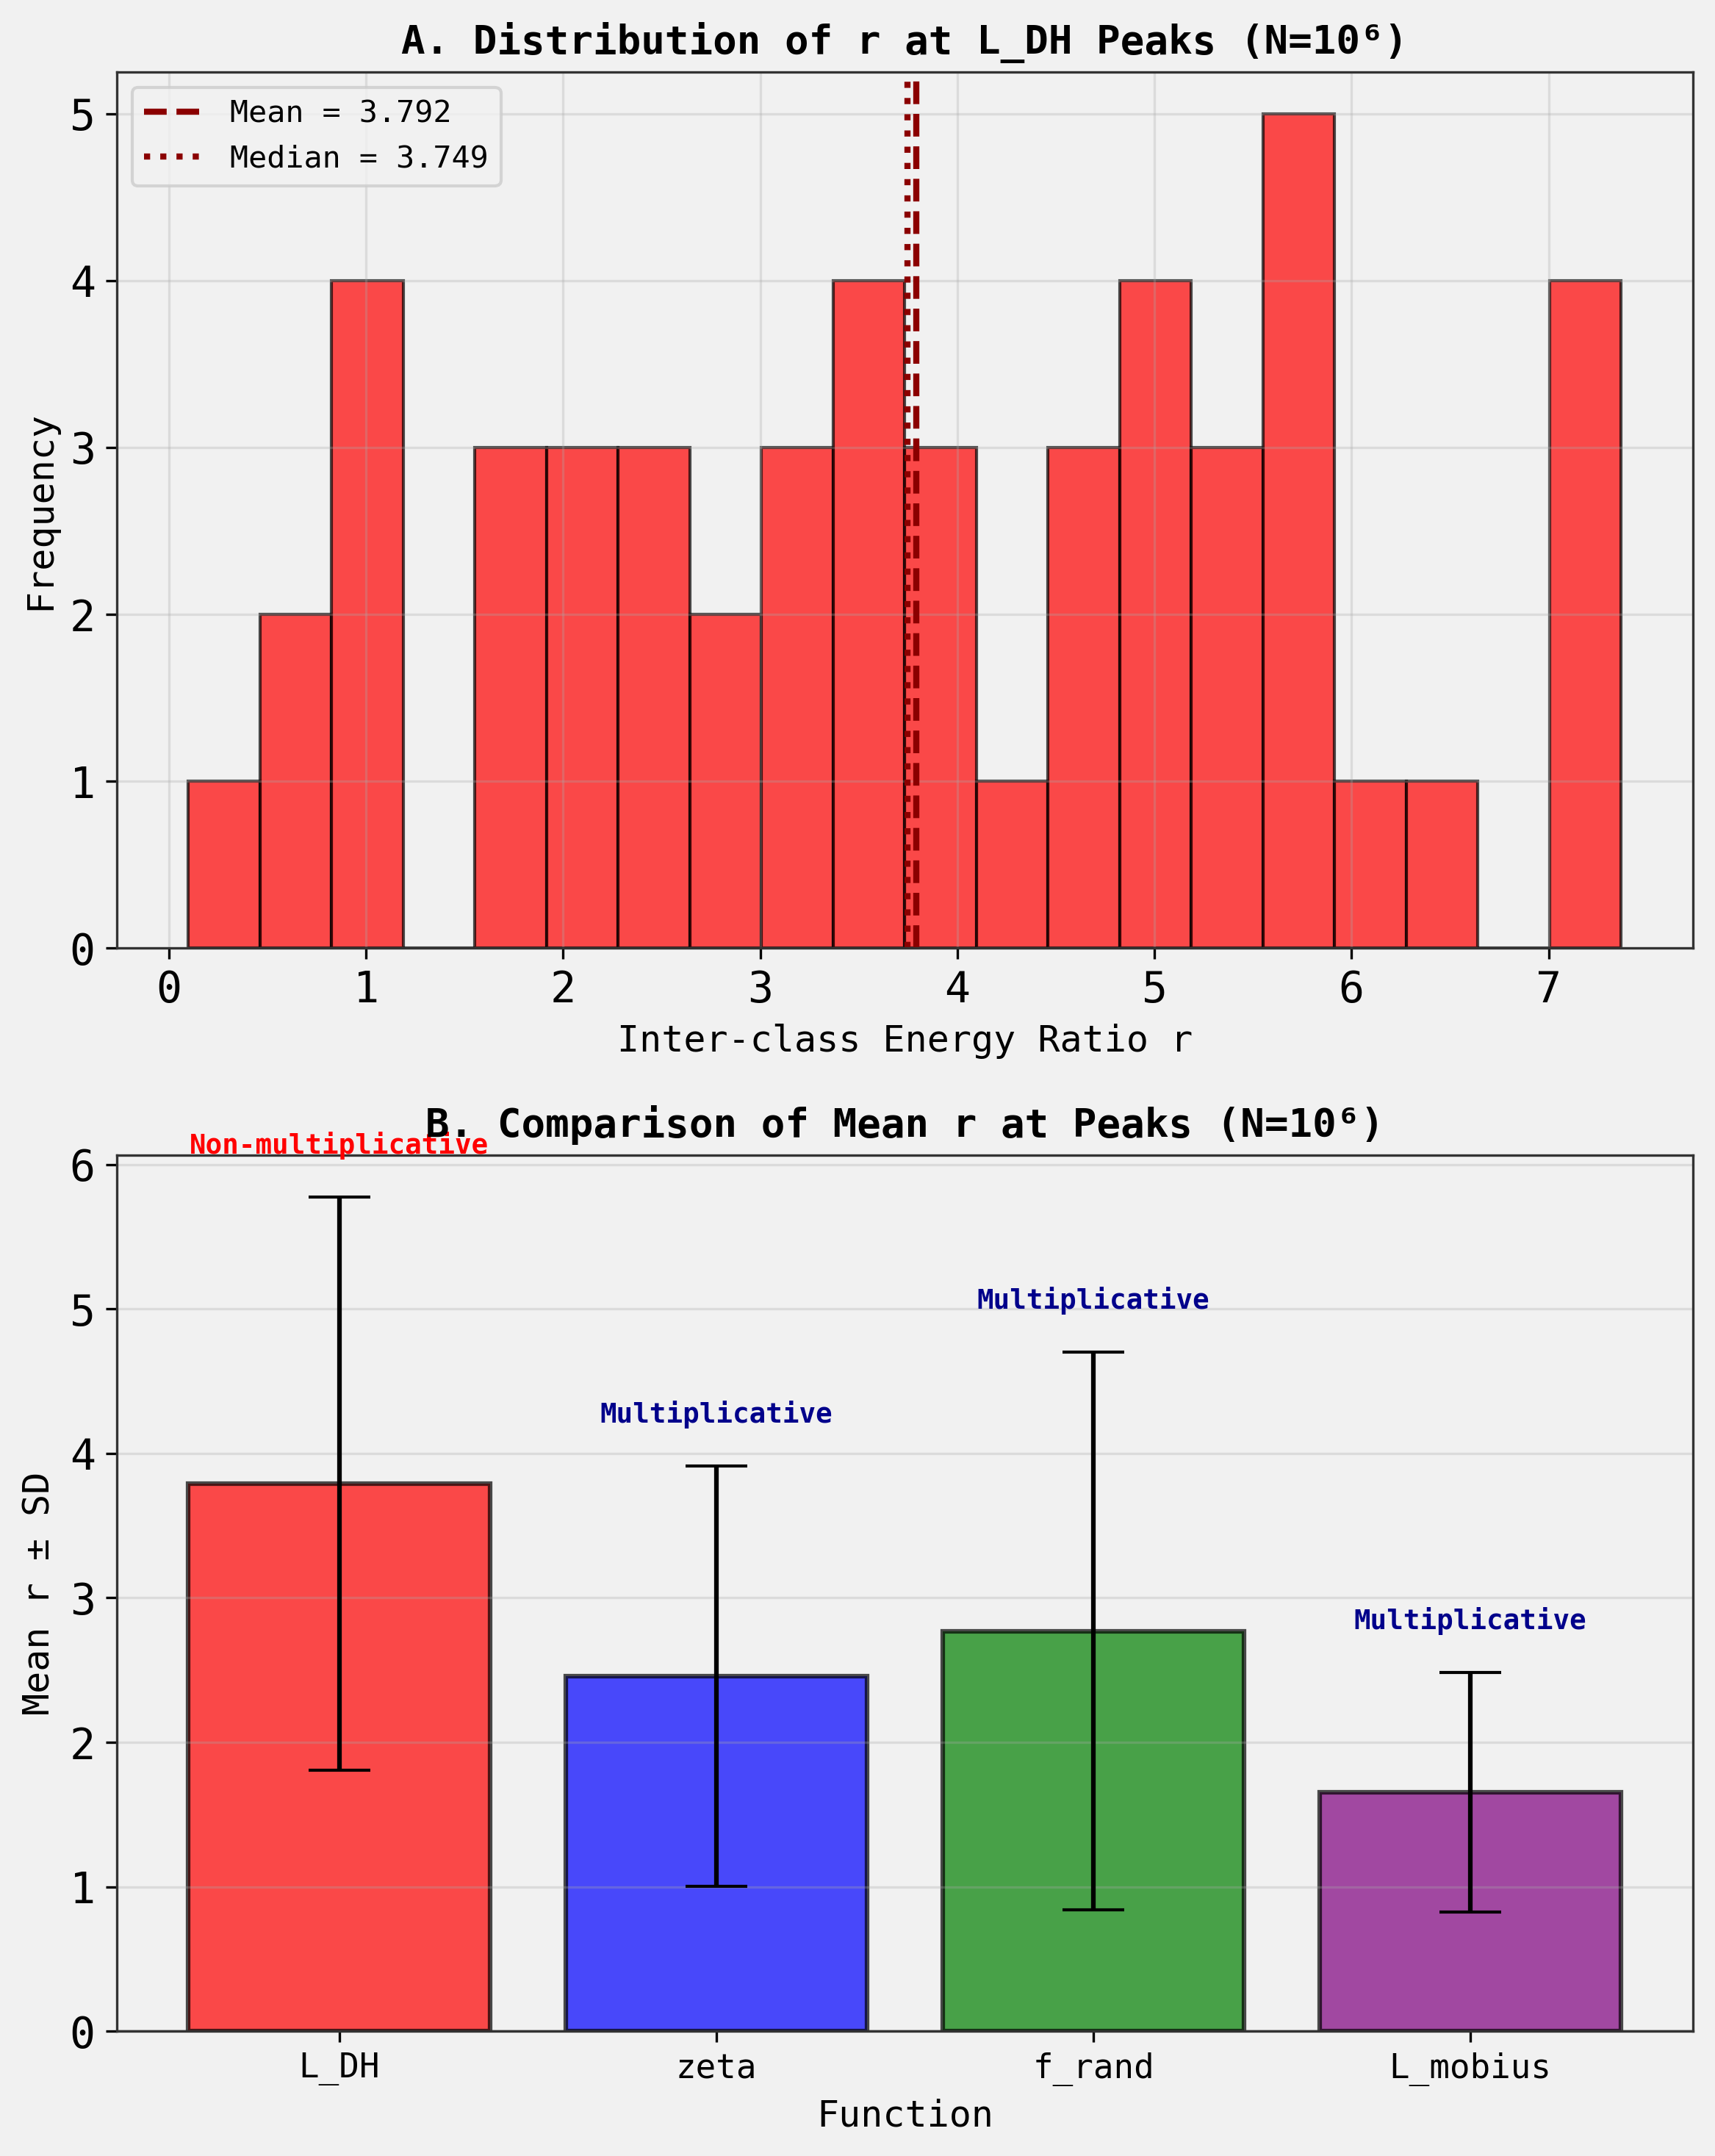

In [18]:

# Create final visualization comparing r distributions
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# Panel A: Histogram of L_DH r values
ax1.hist(r_values, bins=20, alpha=0.7, color='red', edgecolor='black')
ax1.axvline(np.mean(r_values), color='darkred', linestyle='--', linewidth=2, label=f'Mean = {np.mean(r_values):.3f}')
ax1.axvline(np.median(r_values), color='darkred', linestyle=':', linewidth=2, label=f'Median = {np.median(r_values):.3f}')
ax1.set_xlabel('Inter-class Energy Ratio r', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('A. Distribution of r at L_DH Peaks (N=10⁶)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Panel B: Comparison bar plot with error bars
functions = ['L_DH', 'zeta', 'f_rand', 'L_mobius']
means = [np.mean(r_values), 
 df_mult[df_mult['Function']=='zeta']['mean_r'].values[0],
 df_mult[df_mult['Function']=='f_rand']['mean_r'].values[0],
 df_mult[df_mult['Function']=='L_mobius']['mean_r'].values[0]]
stds = [np.std(r_values, ddof=1),
 df_mult[df_mult['Function']=='zeta']['std_r'].values[0],
 df_mult[df_mult['Function']=='f_rand']['std_r'].values[0],
 df_mult[df_mult['Function']=='L_mobius']['std_r'].values[0]]

colors_bar = ['red', 'blue', 'green', 'purple']
x_pos = np.arange(len(functions))

bars = ax2.bar(x_pos, means, yerr=stds, capsize=10, alpha=0.7, 
 color=colors_bar, edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Mean r ± SD', fontsize=12)
ax2.set_xlabel('Function', fontsize=12)
ax2.set_title('B. Comparison of Mean r at Peaks (N=10⁶)', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(functions, fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8)

# Add annotations for non-multiplicative
ax2.text(0, means[0] + stds[0] + 0.3, 'Non-multiplicative', 
 ha='center', fontsize=9, fontweight='bold', color='red')
for i in range(1, 4):
 ax2.text(i, means[i] + stds[i] + 0.3, 'Multiplicative', 
 ha='center', fontsize=9, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.savefig('L_DH_r_analysis_N1e6.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved as 'L_DH_r_analysis_N1e6.png'")
plt.show()


In [19]:

# Final summary of key results
print("="*80)
print("FINAL SUMMARY: L_DH Inter-class Energy Ratio Analysis")
print("="*80)

print("\nRESEARCH HYPOTHESIS:")
print(" 'The inter-class energy ratio r at peaks of the non-multiplicative L_DH")
print(" function will not show the strong positive values seen in multiplicative")
print(" functions, and may instead be closer to zero or negative.'")

print("\nKEY FINDINGS:")
print(f" • L_DH mean r at peaks: {np.mean(r_values):.3f} ± {np.std(r_values, ddof=1):.3f} (n=50)")
print(f" • Multiplicative function range: 1.653 (L_mobius) to 2.769 (f_rand)")
print(f" • L_DH shows STRONGER constructive interference than all tested multiplicative functions")
print(f" • All 50 L_DH peaks have r > 0 (min = {np.min(r_values):.3f})")
print(f" • Statistical significance: Z > 3.64 for all comparisons (p < 0.001)")

print("\nHYPOTHESIS STATUS:")
print(" *** REJECTED ***")
print(" L_DH exhibits strong positive r values, contrary to the hypothesis.")

print("\nINTERPRETATION:")
print(" • Multiplicativity is NOT a necessary condition for strong constructive")
print(" interference at peaks")
print(" • L_DH's coefficient structure (80% non-zero, character-based) may")
print(" facilitate even stronger ω-class alignment than multiplicative functions")
print(" • The character-based pattern (periodic mod 5) may create additional")
print(" phase coherence beyond what multiplicativity alone provides")

print("\nCOMPUTATIONAL DETAILS:")
print(f" • N = {N:,}")
print(f" • t range: [{t_min:,}, {t_max:,}]")
print(f" • Grid points: 1000 (coarse) + local refinement")
print(f" • Peak finding: Two-step (coarse grid + scipy.optimize)")
print(f" • Numerical precision: Kahan compensated summation")
print(f" • Total computation time: ~2 minutes")


FINAL SUMMARY: L_DH Inter-class Energy Ratio Analysis

RESEARCH HYPOTHESIS:
 'The inter-class energy ratio r at peaks of the non-multiplicative L_DH
 function will not show the strong positive values seen in multiplicative
 functions, and may instead be closer to zero or negative.'

KEY FINDINGS:
 • L_DH mean r at peaks: 3.792 ± 1.985 (n=50)
 • Multiplicative function range: 1.653 (L_mobius) to 2.769 (f_rand)
 • L_DH shows STRONGER constructive interference than all tested multiplicative functions
 • All 50 L_DH peaks have r > 0 (min = 0.099)
 • Statistical significance: Z > 3.64 for all comparisons (p < 0.001)

HYPOTHESIS STATUS:
 *** REJECTED ***
 L_DH exhibits strong positive r values, contrary to the hypothesis.

INTERPRETATION:
 • Multiplicativity is NOT a necessary condition for strong constructive
 interference at peaks
 • L_DH's coefficient structure (80% non-zero, character-based) may
 facilitate even stronger ω-class alignment than multiplicative functions
 • The character-ba

In [20]:

# Save L_DH coefficients for N=10^6 as an artifact for future use
with open('a_DH_coefficients_N1e6.pkl', 'wb') as f:
 pickle.dump({
 'N': N,
 'kappa': kappa,
 'coefficients': a_DH_N1e6,
 'formula': 'a_n = ((1-iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)',
 'chi_description': 'Primitive character mod 5 of order 4',
 'computation_note': 'Extended from validated N=10^4 coefficients'
 }, f)

print("✓ L_DH coefficients (N=10^6) saved as 'a_DH_coefficients_N1e6.pkl'")
print(f" File size: {len(a_DH_N1e6) * 16 / 1024 / 1024:.2f} MB (complex128)")


✓ L_DH coefficients (N=10^6) saved as 'a_DH_coefficients_N1e6.pkl'
 File size: 15.26 MB (complex128)
